In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advertisingcsv/Advertising.csv


In [2]:
#Loading the dataset
data=pd.read_csv("../input/advertisingcsv/Advertising.csv")

In [3]:
#Looking some column by using .head 
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
###Lets check dtype and missing valus by using info command
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
#checking of missing values
data.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [6]:
data.describe()


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


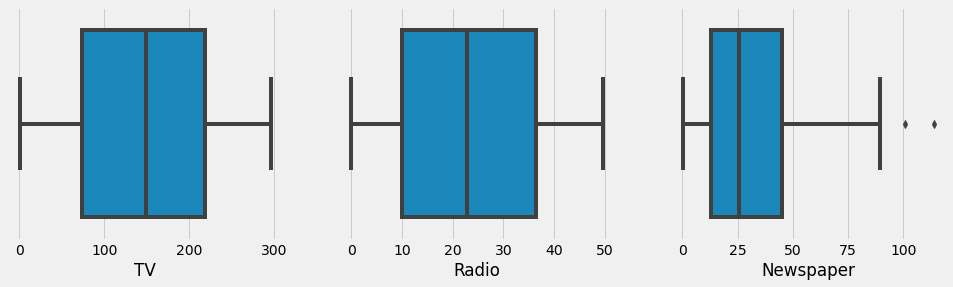

In [7]:
#Visualizing the outlier
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize']=(15,4)

plt.subplot(1,3,1)
sns.boxplot(data['TV'])

plt.subplot(1,3,2)
sns.boxplot(data['Radio'])

plt.subplot(1,3,3)
sns.boxplot(data['Newspaper'])

plt.show()


In [8]:
#####As it is seen that Newspaper column has some outlier

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

<AxesSubplot:xlabel='Newspaper', ylabel='Density'>

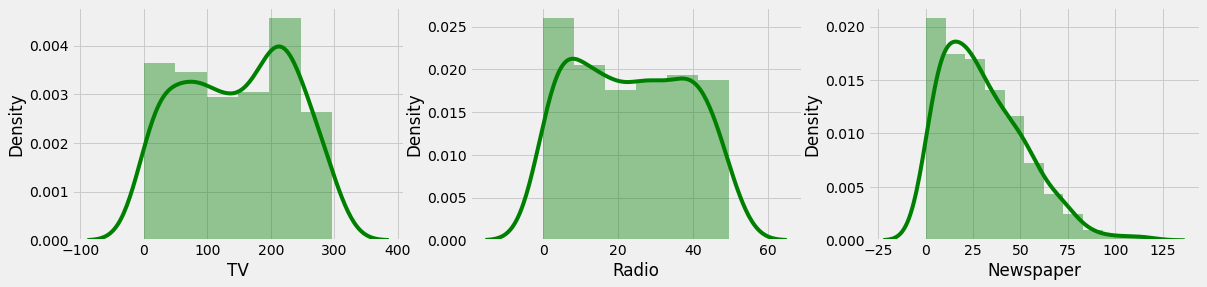

In [9]:
####Performing univariate analyasis

plt.rcParams['figure.figsize']=(18,4)

plt.subplot(1,3,1)
sns.distplot(data['TV'],color='green')

plt.subplot(1,3,2)
sns.distplot(data['Radio'],color='green')

plt.subplot(1,3,3)
sns.distplot(data['Newspaper'],color='green')



/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Sales', ylabel='Density'>

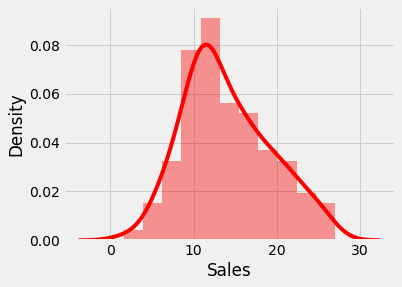

In [10]:
plt.subplot(1,3,1)
sns.distplot(data['Sales'],color='red')

In [11]:
data=data.drop('Unnamed: 0',axis=1)

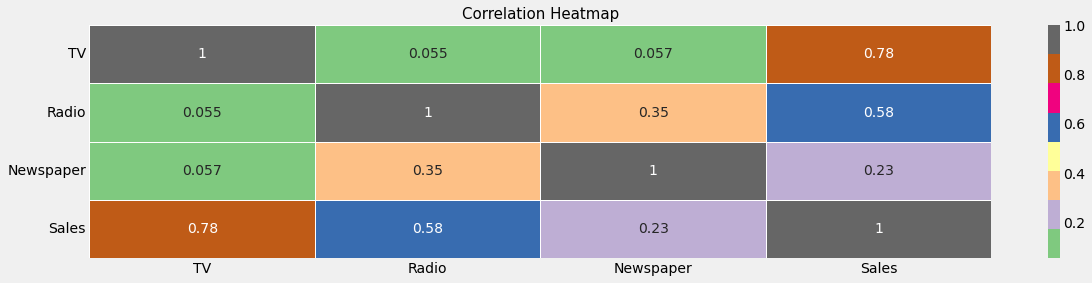

In [12]:
###Performing Multivariate Analyasis

sns.heatmap(data.corr(),annot=True,linewidth=1,cmap='Accent')
plt.title('Correlation Heatmap',fontsize=15)
plt.show()

In [13]:
##Lets remove the outlier from newspaper columns
data=data[data['Newspaper']<100]

In [14]:
data.shape

(198, 4)

In [15]:
#Implementing Linear regression as target column here 'sales' is continous 

y=data['Sales']
x=data.drop(['Sales'],axis=1)
print(y.shape)
print(x.columns)


(198,)
Index(['TV', 'Radio', 'Newspaper'], dtype='object')


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(158, 3)
(40, 3)
(158,)
(40,)


In [17]:
#####Feature scaling (or Normalization)

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [18]:
####Linear regression
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(x_train,y_train)
y_pred1=model1.predict(x_test)

In [19]:
#Lets check RMSE &Mean Squared Error
from sklearn.metrics import r2_score,mean_squared_error
mse=mean_squared_error(y_test,y_pred1)
rmse=np.sqrt(mse)
print(rmse)
r2_score=r2_score(y_test,y_pred1)
print(r2_score)

1.5595116807736777
0.9098946359000558


In [20]:
####Random forest

from sklearn.ensemble import RandomForestRegressor
model2=RandomForestRegressor()
model2.fit(x_train,y_train)
y_pred2=model2.predict(x_test)

In [21]:
from sklearn.metrics import r2_score,mean_squared_error
mse=mean_squared_error(y_test,y_pred2)
rmse=np.sqrt(mse)
print(rmse)
r2_score=r2_score(y_test,y_pred2)
print(r2_score)

0.7679608225684413
0.9781499964340594


In [22]:
####Model is performing well in random forest Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor
model3=GradientBoostingRegressor()
model3.fit(x_train,y_train)
y_pred3=model3.predict(x_test)

In [23]:
from sklearn.metrics import r2_score,mean_squared_error
mse=mean_squared_error(y_test,y_pred3)
rmse=np.sqrt(mse)
print(rmse)
r2_score=r2_score(y_test,y_pred3)
print(r2_score)

0.718617377527078
0.9808676281943134


In [24]:
####Creating Ensemble of the model by averaging
avg_model=(y_pred1+y_pred2+y_pred3)/3
#Creating model accuracy
from sklearn.metrics import r2_score,mean_squared_error
mse=mean_squared_error(y_test,avg_model)
rmse=np.sqrt(mse)
print(rmse)
r2_score=r2_score(y_test,avg_model)
print(r2_score)

0.7568525485349997
0.9787775295635409


In [25]:
###Lets give weights in creating ensemble model and check the score
#lets give 50% wt to gradient boosting
#lets giev 30% wt to random forest
# let give 20% wt to linear model 
wt_avg_model=.2*y_pred1+.3*y_pred2+.5*y_pred3
from sklearn.metrics import r2_score,mean_squared_error
mse=mean_squared_error(y_test,wt_avg_model)
rmse=np.sqrt(mse)
print(rmse)
r2_score=r2_score(y_test,wt_avg_model)
print(r2_score)

0.6889219823290956
0.9824161703746739


In [26]:
##Performing Cross_validation
from sklearn.model_selection import cross_val_score
score=cross_val_score(model3,x,y,cv=5)
print(score)

[0.98159752 0.98656413 0.97271634 0.9630683  0.98659605]


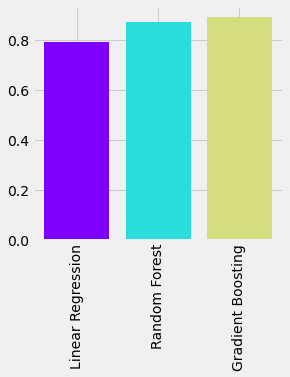

In [27]:
####Comparison of models
r2_score=np.array([.79,.87,.89])
labels=np.array(['Linear Regression','Random Forest','Gradient Boosting'])
index=np.argsort(r2_score)
color=plt.cm.rainbow(np.linspace(0,1,4))

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize']=(4,4)

plt.bar(range(len(index)),r2_score[index],color=color)
plt.xticks(range(0,3),['Linear Regression','Random Forest','Gradient Boosting'],rotation=90)
plt.show()